In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv('social_contracts.csv')
df['timestamp'] = pd.to_datetime(pd.to_numeric(df['timestamp']), unit='ms', utc=True)
df['day'] = df['timestamp'].dt.floor('D')

df.head()

,player_id,friend,timestamp,day
0,13091,10478,2016-01-27 15:53:20+00:00,2016-01-27 00:00:00+00:00
1,13091,10478,2016-01-30 16:06:40+00:00,2016-01-30 00:00:00+00:00
2,13091,10478,2016-02-01 15:20:00+00:00,2016-02-01 00:00:00+00:00
3,13091,10478,2016-02-04 15:33:20+00:00,2016-02-04 00:00:00+00:00
4,13091,10478,2016-02-07 15:46:40+00:00,2016-02-07 00:00:00+00:00


In [ ]:
period_order = ['A', 'B', 'C']

def assign_period(day: pd.Timestamp) -> str:
    if day < pd.Timestamp('2016-02-08', tz='UTC'):
        return 'A'
    if day < pd.Timestamp('2016-03-01', tz='UTC'):
        return 'B'
    return 'C'

df['period'] = df['day'].apply(assign_period)
df['period'] = pd.Categorical(df['period'], categories=period_order, ordered=True)

df.groupby('period', observed=True).size().rename('events').reset_index()

,period,events
0,A,55128
1,B,64017
2,C,152206


In [ ]:
incoming = (
    df.groupby(['period', 'player_id'], observed=True)
      .agg(incoming_count=('player_id', 'size'), incoming_days=('day', 'nunique'))
      .reset_index()
      .rename(columns={'player_id': 'player'})
)

outgoing = (
    df.groupby(['period', 'friend'], observed=True)
      .agg(outgoing_count=('friend', 'size'), outgoing_days=('day', 'nunique'))
      .reset_index()
      .rename(columns={'friend': 'player'})
)

stats = pd.merge(incoming, outgoing, on=['period', 'player'], how='outer')
count_cols = ['incoming_count', 'incoming_days', 'outgoing_count', 'outgoing_days']
stats[count_cols] = stats[count_cols].fillna(0).astype(int)

senders = stats[stats['outgoing_count'] > 0].copy()
senders['io_ratio'] = senders['incoming_count'] / senders['outgoing_count']
senders['io_days_ratio'] = senders['incoming_days'] / senders['outgoing_days']
senders['low_count_receiver'] = senders['io_ratio'] < 0.5
senders['zero_count_receiver'] = senders['incoming_count'] == 0

def set_params(min_days:int=1, io_ratio:float=.8, io_days_ratio:float=.8) -> pd.DataFrame:
  '''
  min_days | int -> minimal number of days a user must complete a contract to be considered a regular sender
  
  io_ratio | float -> ratio of incoming/outgoing counts (contracts) that determines a "low day receiver" -> a sender who receives less then sends
  
  io_days_ratio | float -> ratio of incoming/outgoing days that determines a "low day receiver" -> a sender who receives less then sends
  '''
  min_regular_outgoing_days = min_days # adjustable
  regular_senders = senders[senders['outgoing_days'] >= min_regular_outgoing_days].copy()
  regular_senders['low_day_receiver'] = (regular_senders['io_days_ratio'] <= io_days_ratio) & (regular_senders['io_ratio'] <= io_ratio) # adjustable
  regular_senders['zero_day_receiver'] = regular_senders['incoming_days'] == 0
  return regular_senders

regular_senders = set_params()
regular_senders.head()

,period,player,incoming_count,incoming_days,outgoing_count,outgoing_days,io_ratio,io_days_ratio,low_count_receiver,zero_count_receiver,low_day_receiver,zero_day_receiver
0,A,101,159,15,19,16,8.368421,0.937500,False,False,False,False
1,A,102,16,9,16,14,1.000000,0.642857,False,False,False,False
2,A,104,4,3,15,13,0.266667,0.230769,True,False,True,False
3,A,110,2,1,3,3,0.666667,0.333333,False,False,True,False
4,A,113,5,4,15,10,0.333333,0.400000,True,False,True,False


In [ ]:
# testing edge-cases
regular_senders[(regular_senders['io_days_ratio'] < .5) & (regular_senders['io_ratio'] > 1)]

,period,player,incoming_count,incoming_days,outgoing_count,outgoing_days,io_ratio,io_days_ratio,low_count_receiver,zero_count_receiver,low_day_receiver,zero_day_receiver
1324,A,14615,12,2,7,5,1.714286,0.400000,False,False,False,False
5170,A,77467,4,1,3,3,1.333333,0.333333,False,False,False,False
6235,A,100506,7,1,4,4,1.750000,0.250000,False,False,False,False
8098,A,135741,12,1,5,4,2.400000,0.250000,False,False,False,False
12340,A,193340,4,1,3,3,1.333333,0.333333,False,False,False,False
17525,B,60374,20,1,3,3,6.666667,0.333333,False,False,False,False
21736,B,138664,4,1,3,3,1.333333,0.333333,False,False,False,False
21972,B,142318,13,3,7,7,1.857143,0.428571,False,False,False,False
24898,B,179832,16,3,12,10,1.333333,0.300000,False,False,False,False
28649,B,212216,10,3,8,8,1.250000,0.375000,False,False,False,False


In [ ]:
def get_bayes_summary(df:pd.DataFrame) -> pd.DataFrame:    
    bayes_summary = (
        df
        .groupby('period', observed=True)
        .agg(
            n=('player', 'count'),
            k=('low_day_receiver', 'sum'),
            observed_rate=('low_day_receiver', 'mean')
        )
        .reindex(period_order)
    )

    bayes_summary['observed_rate_pct'] = bayes_summary['observed_rate'] * 100

    # Prior parameters
    prior_alpha = 1
    prior_beta = 1

    # Posterior parameters for each period
    bayes_summary['posterior_alpha'] = prior_alpha + bayes_summary['k']
    bayes_summary['posterior_beta'] = prior_beta + bayes_summary['n'] - bayes_summary['k']

    return bayes_summary 

bayes_summary = get_bayes_summary(regular_senders)

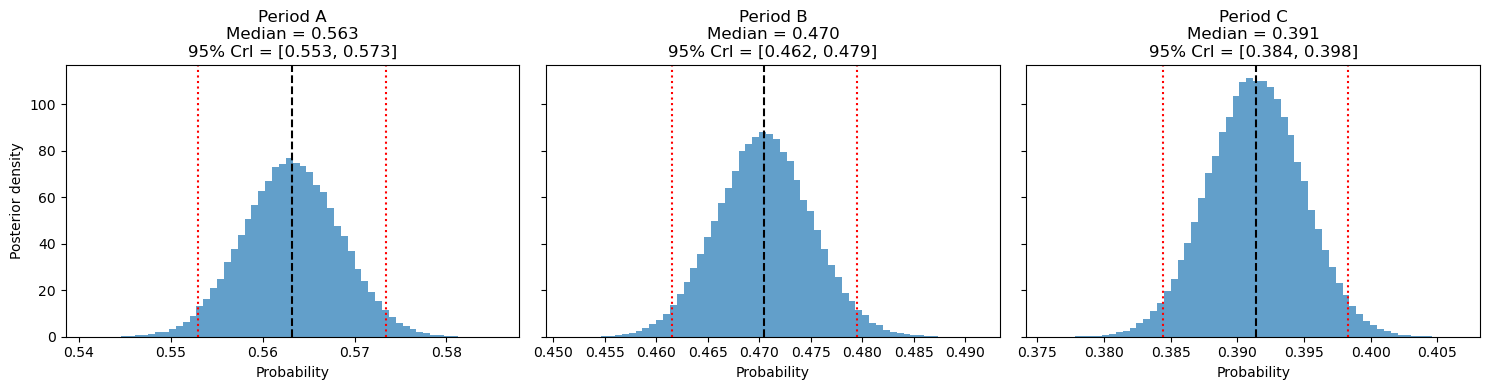

       comparison  probability
0  B lower than A          1.0
1  C lower than A          1.0
2  C lower than B          1.0

Zo 100.000 pripadov pre distribuciu C 100% pripadov bolo mensich ako pre distribuciu A.
Median pravdepodobnost, ze bol regular sender ukrivdeny bola pred 8 februarom 56.32% a po 29 februari bola 39.14% .


In [ ]:
def get_results(bayes_summary:pd.DataFrame) -> None:
    import matplotlib.pyplot as plt

    rng = np.random.default_rng(42)

    n_samples = 100_000

    posterior_samples = {}

    for period in period_order:
        alpha = bayes_summary.loc[period, 'posterior_alpha']
        beta = bayes_summary.loc[period, 'posterior_beta']
        posterior_samples[period] = rng.beta(alpha, beta, size=n_samples)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    medians = []

    for ax, period in zip(axes, period_order):
        samples = posterior_samples[period]
        lower, median, upper = np.quantile(samples, [0.025, 0.5, 0.975])

        ax.hist(samples, bins=60, density=True, alpha=0.7)
        ax.axvline(median, color='black', linestyle='--')
        ax.axvline(lower, color='red', linestyle=':')
        ax.axvline(upper, color='red', linestyle=':')

        ax.set_title(
            f'Period {period}\n'
            f'Median = {median:.3f}\n'
            f'95% CrI = [{lower:.3f}, {upper:.3f}]'
        )
        ax.set_xlabel('Probability')
        medians.append(median)

    axes[0].set_ylabel('Posterior density')
    plt.tight_layout()
    plt.show()

    p_A = posterior_samples['A']
    p_B = posterior_samples['B']
    p_C = posterior_samples['C']

    prob_B_better_than_A = np.mean(p_B < p_A)
    prob_C_better_than_A = np.mean(p_C < p_A)
    prob_C_better_than_B = np.mean(p_C < p_B)

    comparison_probs = pd.DataFrame({
        'comparison': [
            'B lower than A',
            'C lower than A',
            'C lower than B',
        ],
        'probability': [
            prob_B_better_than_A,
            prob_C_better_than_A,
            prob_C_better_than_B,
        ]
    })

    print(comparison_probs, end='\n\n')
    print(f"Zo 100.000 pripadov pre distribuciu C {comparison_probs.iloc[1,1]*100:.0f}% pripadov bolo mensich ako pre distribuciu A.")
    print(f"Median pravdepodobnost, ze bol regular sender ukrivdeny bola pred 8 februarom {medians[0]*100:.2f}% a po 29 februari bola {medians[2]*100:.2f}% .")
get_results(bayes_summary)

# Playground
* `Period A` < 8.Feb
* `Period B` 8.Feb - 29.Feb
* `Period C` > 1.Mar

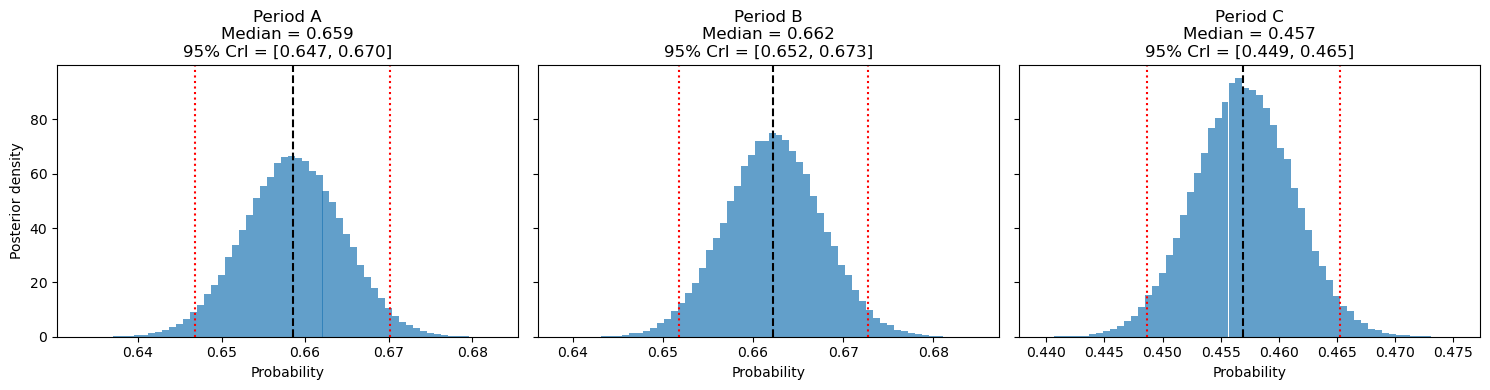

       comparison  probability
0  B lower than A      0.32248
1  C lower than A      1.00000
2  C lower than B      1.00000

Zo 100.000 pripadov pre distribuciu C 100% pripadov bolo mensich ako pre distribuciu A.
Median pravdepodobnost, ze bol regular sender ukrivdeny bola pred 8 februarom 65.86% a po 29 februari bola 45.70% .


In [ ]:
# nastavenie parametrov
min_days = 2 # minimalny pocet dni aby sme povazovali hraca za sendera
io_ratio = .8 # podiel prijatych/odoslanych kontraktov aby sme povazovali hraca za "ukrivdeneho"
io_days_ratio = .9 # podiel dni prijatych/odoslanych kontraktov aby sme povazovali hraca za "ukrivdeneho"


get_results(get_bayes_summary(set_params(min_days=min_days, io_ratio=io_ratio, io_days_ratio=io_days_ratio)))